In [1]:
# ============================================================
# CELL 1 — Imports
# ============================================================

from pathlib import Path
import json
import re
import traceback
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [2]:
# ============================================================
# CELL 2 — Project root
# ============================================================

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:")
print(PROJECT_ROOT)

Project root:
d:\downloads\misleading-health-infographic-detection


In [3]:
# ============================================================
# CELL 3 — Phase 13 directories
# ============================================================

PHASE12_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "phase12"
)

PHASE13_DIR = (
    PROJECT_ROOT /
    "outputs" /
    "phase13"
)

CLAIMS_DIR = (
    PHASE13_DIR /
    "claims"
)

MANIFEST_DIR = (
    PHASE13_DIR /
    "manifests"
)

METRICS_DIR = (
    PHASE13_DIR /
    "metrics"
)

VIS_DIR = (
    PHASE13_DIR /
    "visualizations"
)

REPORTS_DIR = (
    PHASE13_DIR /
    "reports"
)

for directory in [
    PHASE13_DIR,
    CLAIMS_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    VIS_DIR,
    REPORTS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Phase 13 directories created.")

Phase 13 directories created.


In [4]:
# ============================================================
# CELL 4 — Load Phase 12 → Phase 13 input
# ============================================================

PHASE13_INPUT = (
    PHASE12_DIR /
    "manifests" /
    "phase13_claim_extraction_input.csv"
)

print("Input file:")
print(PHASE13_INPUT)

if not PHASE13_INPUT.exists():
    raise FileNotFoundError(
        f"Phase 13 input not found:\n{PHASE13_INPUT}"
    )

phase13_input = pd.read_csv(
    PHASE13_INPUT,
    encoding="utf-8-sig"
)

print("\nShape:")
print(phase13_input.shape)

print("\nColumns:")
print(
    phase13_input.columns.tolist()
)

display(
    phase13_input.head()
)

Input file:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase13_claim_extraction_input.csv

Shape:
(100, 10)

Columns:
['record_key', 'image_path', 'label', 'source', 'phase11_split', 'ocr_text', 'num_text_lines', 'ocr_char_count', 'ocr_word_count', 'ocr_quality']


,record_key,image_path,label,source,phase11_split,ocr_text,num_text_lines,ocr_char_count,ocr_word_count,ocr_quality
0,record_000000,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
1,record_000001,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
2,record_000002,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
3,record_000003,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
4,record_000004,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low


In [5]:
# ============================================================
# CELL 5 — Validate input columns
# ============================================================

REQUIRED_COLUMNS = [
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "ocr_text",
    "num_text_lines",
    "ocr_char_count",
    "ocr_word_count",
    "ocr_quality"
]

missing_columns = [
    col
    for col in REQUIRED_COLUMNS
    if col not in phase13_input.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns:\n"
        + "\n".join(missing_columns)
    )

print("All required columns are present.")

All required columns are present.


In [6]:
# ============================================================
# CELL 6 — Inspect OCR text
# ============================================================

print(
    "Number of records:",
    len(phase13_input)
)

print(
    "Empty OCR texts:",
    phase13_input["ocr_text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("\nSample OCR text:\n")

for _, row in phase13_input.head(5).iterrows():

    print("=" * 70)

    print(
        "Record:",
        row["record_key"]
    )

    print(
        row["ocr_text"]
    )

Number of records: 100
Empty OCR texts: 0

Sample OCR text:

Record: record_000000
WebMD
Record: record_000001
WebMD
Record: record_000002
WebMD
Record: record_000003
WebMD
Record: record_000004
WebMD


In [7]:
# ============================================================
# CELL 7 — OCR normalization
# ============================================================

def normalize_ocr_text(text):
    """
    Conservative OCR normalization.

    Does not attempt to correct medical terminology.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Normalize whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    # Remove obvious repeated punctuation
    text = re.sub(
        r"([!?.,])\1{2,}",
        r"\1",
        text
    )

    # Strip whitespace
    text = text.strip()

    return text


phase13_input["clean_ocr_text"] = (
    phase13_input["ocr_text"]
    .apply(normalize_ocr_text)
)

print("OCR normalization complete.")

display(
    phase13_input[
        [
            "record_key",
            "ocr_text",
            "clean_ocr_text"
        ]
    ].head()
)

OCR normalization complete.


,record_key,ocr_text,clean_ocr_text
0,record_000000,WebMD,WebMD
1,record_000001,WebMD,WebMD
2,record_000002,WebMD,WebMD
3,record_000003,WebMD,WebMD
4,record_000004,WebMD,WebMD


In [8]:
# ============================================================
# CELL 8 — Sentence segmentation
# ============================================================

def split_into_sentences(text):
    """
    Lightweight sentence segmentation.

    Designed for OCR text rather than long-form prose.
    """

    if not text:
        return []

    # Normalize line breaks
    text = re.sub(
        r"[\r\n]+",
        ". ",
        text
    )

    # Split around sentence punctuation
    parts = re.split(
        r"(?<=[.!?])\s+|;\s+|\|\s+",
        text
    )

    sentences = []

    for part in parts:

        part = part.strip()

        if len(part) >= 3:
            sentences.append(part)

    return sentences


phase13_input["sentences"] = (
    phase13_input["clean_ocr_text"]
    .apply(split_into_sentences)
)

phase13_input["num_sentences"] = (
    phase13_input["sentences"]
    .apply(len)
)

print("Sentence segmentation complete.")

display(
    phase13_input[
        [
            "record_key",
            "sentences",
            "num_sentences"
        ]
    ].head()
)

Sentence segmentation complete.


,record_key,sentences,num_sentences
0,record_000000,[WebMD],1
1,record_000001,[WebMD],1
2,record_000002,[WebMD],1
3,record_000003,[WebMD],1
4,record_000004,[WebMD],1


In [9]:
# ============================================================
# CELL 9 — Claim indicators
# ============================================================

HEALTH_TERMS = [
    "health",
    "healthy",
    "disease",
    "illness",
    "symptom",
    "symptoms",
    "treatment",
    "treat",
    "cure",
    "prevent",
    "prevention",
    "risk",
    "infection",
    "virus",
    "bacteria",
    "cancer",
    "diabetes",
    "blood pressure",
    "cholesterol",
    "heart",
    "weight",
    "obesity",
    "vitamin",
    "mineral",
    "protein",
    "supplement",
    "medicine",
    "medication",
    "drug",
    "diet",
    "food",
    "nutrition",
    "immune",
    "immunity",
    "brain",
    "sleep",
    "exercise",
    "calorie",
    "fat",
    "sugar",
    "blood",
    "doctor",
    "medical",
    "therapy"
]

CLAIM_VERBS = [
    "cause",
    "causes",
    "caused",
    "prevent",
    "prevents",
    "prevented",
    "reduce",
    "reduces",
    "increases",
    "increase",
    "decrease",
    "decreases",
    "improve",
    "improves",
    "boost",
    "boosts",
    "lower",
    "lowers",
    "raise",
    "raises",
    "protect",
    "protects",
    "cure",
    "cures",
    "treat",
    "treats",
    "heal",
    "heals",
    "lead",
    "leads",
    "associated",
    "linked"
]

CLAIM_PATTERNS = [
    r"\bcan\b",
    r"\bmay\b",
    r"\bwill\b",
    r"\bhelps?\b",
    r"\bprevents?\b",
    r"\bcauses?\b",
    r"\breduces?\b",
    r"\bincreases?\b",
    r"\bimproves?\b",
    r"\bboosts?\b",
    r"\bprotects?\b",
    r"\bcures?\b",
    r"\btreats?\b",
    r"\bassociated with\b",
    r"\blinked to\b",
    r"\b\d+\s*%\b",
    r"\b\d+\s*(mg|g|kg|ml|calories|years|days)\b"
]

print("Claim indicators loaded.")

Claim indicators loaded.


In [10]:
# ============================================================
# CELL 10 — Identify candidate claims
# ============================================================

def is_candidate_claim(sentence):
    """
    Identify whether a sentence contains claim-like
    health information.

    This is candidate extraction, NOT truth verification.
    """

    if not sentence:
        return False

    text = sentence.lower().strip()

    # Too short
    if len(text) < 15:
        return False

    # Contains health terminology
    contains_health_term = any(
        term in text
        for term in HEALTH_TERMS
    )

    # Contains claim verb
    contains_claim_verb = any(
        verb in text
        for verb in CLAIM_VERBS
    )

    # Contains numerical/claim pattern
    contains_claim_pattern = any(
        re.search(
            pattern,
            text
        )
        for pattern in CLAIM_PATTERNS
    )

    # Strong candidate
    if (
        contains_health_term
        and (
            contains_claim_verb
            or contains_claim_pattern
        )
    ):
        return True

    # Explicit quantitative statement
    if contains_claim_pattern:
        return True

    return False

In [11]:
# ============================================================
# CELL 11 — Extract candidate claims
# ============================================================

candidate_records = []

for _, row in phase13_input.iterrows():

    sentences = row["sentences"]

    for sentence_index, sentence in enumerate(
        sentences
    ):

        if is_candidate_claim(sentence):

            candidate_records.append({

                "record_key":
                    row["record_key"],

                "image_path":
                    row["image_path"],

                "label":
                    row["label"],

                "source":
                    row["source"],

                "phase11_split":
                    row["phase11_split"],

                "sentence_index":
                    sentence_index,

                "claim_text":
                    sentence

            })

candidate_claims_df = pd.DataFrame(
    candidate_records
)

print(
    "Candidate claims:",
    len(candidate_claims_df)
)

display(
    candidate_claims_df.head(20)
)

Candidate claims: 12


,record_key,image_path,label,source,phase11_split,sentence_index,claim_text
0,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,1,"The purpose of this campaign is, ""to help redu..."
1,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,0,10 Multi-dose Vials No Preservative Each vial ...
2,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,3,10 Multi-dose Vials No Preservative Each vial ...
3,record_000073,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,0,-19 Vaccine COVID-19 Vaccine contains 6 doses ...
4,record_000077,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,0,Mutio 50 L01EXP ABV606 Intan (ChA) COVD 8 Inie...
5,record_000088,D:\downloads\misleading-health-infographic-det...,0,Med-MMHL,Med-MMHL,0,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...
6,record_000090,D:\downloads\misleading-health-infographic-det...,1,Med-MMHL,Med-MMHL,0,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...
7,record_000121,D:\downloads\misleading-health-infographic-det...,1,ReCOVery,ReCOVery,1,"The purpose of this campaign is, ""to help redu..."
8,record_000136,D:\downloads\misleading-health-infographic-det...,0,ReCOVery,ReCOVery,0,10 Multi-dose Vials No Preservative Each vial ...
9,record_000136,D:\downloads\misleading-health-infographic-det...,0,ReCOVery,ReCOVery,3,10 Multi-dose Vials No Preservative Each vial ...


In [12]:
# ============================================================
# CELL 12 — Claims per record
# ============================================================

claims_per_record = (
    candidate_claims_df
    .groupby("record_key")
    .size()
    .reset_index(
        name="num_candidate_claims"
    )
)

phase13_input = phase13_input.merge(
    claims_per_record,
    on="record_key",
    how="left"
)

phase13_input["num_candidate_claims"] = (
    phase13_input["num_candidate_claims"]
    .fillna(0)
    .astype(int)
)

print(
    phase13_input[
        "num_candidate_claims"
    ].describe()
)

count    100.000000
mean       0.120000
std        0.383498
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        2.000000
Name: num_candidate_claims, dtype: float64


In [13]:
# ============================================================
# CELL 13 — Claim type classification
# ============================================================

def classify_claim_type(text):

    text_lower = text.lower()

    if re.search(
        r"\b(cause|causes|caused by|leads to|results in)\b",
        text_lower
    ):
        return "causal"

    if re.search(
        r"\b(prevent|prevents|prevention|protect|protects)\b",
        text_lower
    ):
        return "preventive"

    if re.search(
        r"\b(treat|treats|treatment|cure|cures|therapy|heal)\b",
        text_lower
    ):
        return "therapeutic"

    if re.search(
        r"\b(risk|associated|association|linked|link)\b",
        text_lower
    ):
        return "risk_association"

    if re.search(
        r"\b\d+\s*%",
        text_lower
    ) or re.search(
        r"\b\d+\s*(mg|g|kg|ml|calories|days|years)\b",
        text_lower
    ):
        return "quantitative"

    if re.search(
        r"\b(should|must|need to|recommend|recommended)\b",
        text_lower
    ):
        return "recommendation"

    if any(
        term in text_lower
        for term in HEALTH_TERMS
    ):
        return "general_health"

    return "unknown"


candidate_claims_df["claim_type"] = (
    candidate_claims_df["claim_text"]
    .apply(classify_claim_type)
)

print(
    candidate_claims_df[
        "claim_type"
    ].value_counts()
)

claim_type
quantitative    8
unknown         4
Name: count, dtype: int64


In [14]:
# ============================================================
# CELL 14 — Health topic extraction
# ============================================================

TOPIC_TERMS = {

    "nutrition": [
        "food",
        "diet",
        "nutrition",
        "protein",
        "carbohydrate",
        "fat",
        "calorie"
    ],

    "vitamins_minerals": [
        "vitamin",
        "vitamin d",
        "vitamin c",
        "vitamin b",
        "iron",
        "calcium",
        "zinc",
        "magnesium"
    ],

    "cardiovascular": [
        "heart",
        "blood pressure",
        "cholesterol",
        "cardiovascular"
    ],

    "diabetes": [
        "diabetes",
        "blood sugar",
        "glucose",
        "insulin"
    ],

    "cancer": [
        "cancer",
        "tumor",
        "tumour",
        "malignant"
    ],

    "immunity": [
        "immune",
        "immunity",
        "infection"
    ],

    "mental_health": [
        "stress",
        "anxiety",
        "depression",
        "mental health"
    ],

    "sleep": [
        "sleep",
        "insomnia"
    ],

    "weight": [
        "weight loss",
        "weight gain",
        "obesity",
        "overweight"
    ],

    "exercise": [
        "exercise",
        "workout",
        "physical activity"
    ]
}


def extract_topics(text):

    text_lower = text.lower()

    topics = []

    for topic, terms in TOPIC_TERMS.items():

        if any(
            term in text_lower
            for term in terms
        ):
            topics.append(topic)

    if not topics:
        topics.append("other")

    return topics


candidate_claims_df["topics"] = (
    candidate_claims_df["claim_text"]
    .apply(extract_topics)
)

display(
    candidate_claims_df[
        [
            "claim_text",
            "claim_type",
            "topics"
        ]
    ].head(20)
)

,claim_text,claim_type,topics
0,"The purpose of this campaign is, ""to help redu...",unknown,[other]
1,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other]
2,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other]
3,-19 Vaccine COVID-19 Vaccine contains 6 doses ...,quantitative,[other]
4,Mutio 50 L01EXP ABV606 Intan (ChA) COVD 8 Inie...,quantitative,[other]
5,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...,unknown,[other]
6,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...,unknown,[other]
7,"The purpose of this campaign is, ""to help redu...",unknown,[other]
8,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other]
9,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other]


In [15]:
# ============================================================
# CELL 15 — Extract quantitative information
# ============================================================

def extract_numbers(text):

    patterns = [

        r"\b\d+(?:\.\d+)?\s*%",

        r"\b\d+(?:\.\d+)?\s*(?:mg|g|kg|ml|l)\b",

        r"\b\d+(?:\.\d+)?\s*(?:days?|weeks?|months?|years?)\b",

        r"\b\d+(?:\.\d+)?\b"
    ]

    matches = []

    for pattern in patterns:

        matches.extend(
            re.findall(
                pattern,
                text,
                flags=re.IGNORECASE
            )
        )

    # Remove duplicates
    return list(
        dict.fromkeys(matches)
    )


candidate_claims_df["quantitative_values"] = (
    candidate_claims_df["claim_text"]
    .apply(extract_numbers)
)

candidate_claims_df["has_quantitative_value"] = (
    candidate_claims_df[
        "quantitative_values"
    ].apply(len) > 0
)

display(
    candidate_claims_df[
        [
            "claim_text",
            "quantitative_values"
        ]
    ].head(20)
)

,claim_text,quantitative_values
0,"The purpose of this campaign is, ""to help redu...",[]
1,10 Multi-dose Vials No Preservative Each vial ...,"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
2,10 Multi-dose Vials No Preservative Each vial ...,"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
3,-19 Vaccine COVID-19 Vaccine contains 6 doses ...,"[0.3 mL, 19, 6, 0.3]"
4,Mutio 50 L01EXP ABV606 Intan (ChA) COVD 8 Inie...,"[5ml, 50, 8, 19, 07, 20, 4, 10, 8127, 2021, 9]"
5,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...,[]
6,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...,[]
7,"The purpose of this campaign is, ""to help redu...",[]
8,10 Multi-dose Vials No Preservative Each vial ...,"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
9,10 Multi-dose Vials No Preservative Each vial ...,"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"


In [16]:
# ============================================================
# CELL 16 — Generate claim IDs
# ============================================================

candidate_claims_df = (
    candidate_claims_df
    .reset_index(drop=True)
)

candidate_claims_df["claim_id"] = [
    f"claim_{i:06d}"
    for i in range(
        len(candidate_claims_df)
    )
]

# Put claim_id first
columns = [
    "claim_id"
] + [
    col
    for col in candidate_claims_df.columns
    if col != "claim_id"
]

candidate_claims_df = (
    candidate_claims_df[
        columns
    ]
)

print(
    "Total claim objects:",
    len(candidate_claims_df)
)

display(
    candidate_claims_df.head()
)

Total claim objects: 12


,claim_id,record_key,image_path,label,source,phase11_split,sentence_index,claim_text,claim_type,topics,quantitative_values,has_quantitative_value
0,claim_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,1,"The purpose of this campaign is, ""to help redu...",unknown,[other],[],False
1,claim_000001,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,0,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other],"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]",True
2,claim_000002,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,3,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other],"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]",True
3,claim_000003,record_000073,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,0,-19 Vaccine COVID-19 Vaccine contains 6 doses ...,quantitative,[other],"[0.3 mL, 19, 6, 0.3]",True
4,claim_000004,record_000077,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,0,Mutio 50 L01EXP ABV606 Intan (ChA) COVD 8 Inie...,quantitative,[other],"[5ml, 50, 8, 19, 07, 20, 4, 10, 8127, 2021, 9]",True


In [17]:
# ============================================================
# CELL 17 — Build record-level claim objects
# ============================================================

record_claim_objects = {}

for record_key, group in (
    candidate_claims_df
    .groupby("record_key")
):

    claims = []

    for _, row in group.iterrows():

        claims.append({

            "claim_id":
                row["claim_id"],

            "claim_text":
                row["claim_text"],

            "claim_type":
                row["claim_type"],

            "topics":
                row["topics"],

            "quantitative_values":
                row["quantitative_values"],

            "has_quantitative_value":
                bool(
                    row[
                        "has_quantitative_value"
                    ]
                ),

            "sentence_index":
                int(
                    row[
                        "sentence_index"
                    ]
                )
        })

    original_row = (
        phase13_input[
            phase13_input[
                "record_key"
            ] == record_key
        ]
        .iloc[0]
    )

    record_claim_objects[
        record_key
    ] = {

        "record_key":
            record_key,

        "image_path":
            original_row[
                "image_path"
            ],

        "label":
            original_row[
                "label"
            ],

        "source":
            original_row[
                "source"
            ],

        "phase11_split":
            original_row[
                "phase11_split"
            ],

        "ocr_text":
            original_row[
                "clean_ocr_text"
            ],

        "num_claims":
            len(claims),

        "claims":
            claims
    }


print(
    "Record-level claim objects:",
    len(record_claim_objects)
)

Record-level claim objects: 10


In [20]:
# ============================================================
# CELL 18 — Save record-level claim JSONs
# Robust JSON serialization for NumPy/Pandas objects
# ============================================================

def make_json_serializable(obj):
    """
    Recursively convert NumPy/Pandas objects into
    standard Python objects that JSON can serialize.
    """

    # --------------------------------------------------------
    # None
    # --------------------------------------------------------
    if obj is None:
        return None

    # --------------------------------------------------------
    # Path
    # --------------------------------------------------------
    if isinstance(obj, Path):
        return str(obj)

    # --------------------------------------------------------
    # Dictionary
    # --------------------------------------------------------
    if isinstance(obj, dict):
        return {
            str(key): make_json_serializable(value)
            for key, value in obj.items()
        }

    # --------------------------------------------------------
    # List / tuple / set
    # --------------------------------------------------------
    if isinstance(obj, (list, tuple, set)):
        return [
            make_json_serializable(value)
            for value in obj
        ]

    # --------------------------------------------------------
    # NumPy ndarray
    # --------------------------------------------------------
    if isinstance(obj, np.ndarray):
        return [
            make_json_serializable(value)
            for value in obj.tolist()
        ]

    # --------------------------------------------------------
    # NumPy scalar types
    # --------------------------------------------------------
    if isinstance(obj, np.generic):
        return make_json_serializable(
            obj.item()
        )

    # --------------------------------------------------------
    # Pandas Timestamp
    # --------------------------------------------------------
    if isinstance(obj, pd.Timestamp):
        return obj.isoformat()

    # --------------------------------------------------------
    # Pandas NA
    # --------------------------------------------------------
    if obj is pd.NA:
        return None

    # --------------------------------------------------------
    # Regular float NaN
    # --------------------------------------------------------
    if isinstance(obj, float):
        if np.isnan(obj):
            return None

        return obj

    # --------------------------------------------------------
    # Regular scalar Pandas NA check
    # --------------------------------------------------------
    try:
        missing = pd.isna(obj)

        # Only use the result if it is a single boolean.
        if isinstance(
            missing,
            (bool, np.bool_)
        ):
            if bool(missing):
                return None

    except (TypeError, ValueError):
        pass

    # --------------------------------------------------------
    # Already JSON-safe
    # --------------------------------------------------------
    return obj


# ============================================================
# Save all record-level JSON files
# ============================================================

saved_count = 0
failed_count = 0

failed_records = []

for record_key, data in record_claim_objects.items():

    output_path = (
        CLAIMS_DIR /
        f"{record_key}.json"
    )

    try:

        # Convert EVERYTHING recursively
        json_safe_data = make_json_serializable(
            data
        )

        with open(
            output_path,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                json_safe_data,
                f,
                indent=2,
                ensure_ascii=False
            )

        saved_count += 1

    except Exception as e:

        failed_count += 1

        failed_records.append({
            "record_key": record_key,
            "error": str(e)
        })

        print(
            f"ERROR saving {record_key}: {e}"
        )


print("=" * 60)

print(
    "Record JSON files saved:",
    saved_count
)

print(
    "Failed:",
    failed_count
)

if failed_records:

    print("\nFailed records:")

    for item in failed_records:
        print(
            item["record_key"],
            "->",
            item["error"]
        )

Record JSON files saved: 10
Failed: 0


In [21]:
# ============================================================
# CELL 18A — Verify saved claim JSON files
# ============================================================

json_files = sorted(
    CLAIMS_DIR.glob("record_*.json")
)

print(
    "JSON files found:",
    len(json_files)
)

print(
    "Expected records:",
    len(record_claim_objects)
)

print("\nFirst few files:")

for path in json_files[:10]:
    print(
        "✓",
        path.name
    )

JSON files found: 10
Expected records: 10

First few files:
✓ record_000050.json
✓ record_000062.json
✓ record_000073.json
✓ record_000077.json
✓ record_000088.json
✓ record_000090.json
✓ record_000121.json
✓ record_000136.json
✓ record_000147.json
✓ record_000151.json


In [22]:
# ============================================================
# CELL 18B — Inspect one saved claim JSON
# ============================================================

if json_files:

    sample_json_path = json_files[0]

    with open(
        sample_json_path,
        "r",
        encoding="utf-8"
    ) as f:

        sample_json = json.load(f)

    print(
        json.dumps(
            sample_json,
            indent=2,
            ensure_ascii=False
        )[:5000]
    )

{
  "record_key": "record_000050",
  "image_path": "D:\\downloads\\misleading-health-infographic-detection\\outputs\\phase10\\images\\MMCoVar\\1689.jpg",
  "label": 0,
  "source": "MMCoVar",
  "phase11_split": "MMCoVar",
  "ocr_text": "BANTHIS.TV brittlynnrising 15h Here are the screenshots! The purpose of this campaign is, \"to help reduce hesitance and encourage people to get the vaccine.\" That is a direct quote from the email. ① Visit the COVID-19 Information Center for",
  "num_claims": 1,
  "claims": [
    {
      "claim_id": "claim_000000",
      "claim_text": "The purpose of this campaign is, \"to help reduce hesitance and encourage people to get the vaccine.\" That is a direct quote from the email.",
      "claim_type": "unknown",
      "topics": [
        "other"
      ],
      "quantitative_values": [],
      "has_quantitative_value": false,
      "sentence_index": 1
    }
  ]
}


In [23]:
# ============================================================
# CELL 19 — Save claim manifest
# ============================================================

CLAIM_MANIFEST_PATH = (
    MANIFEST_DIR /
    "phase13_claims_manifest.csv"
)

candidate_claims_df.to_csv(
    CLAIM_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Claim manifest saved:")
print(CLAIM_MANIFEST_PATH)

print(
    "\nShape:",
    candidate_claims_df.shape
)

Claim manifest saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13\manifests\phase13_claims_manifest.csv

Shape: (12, 12)


In [24]:
# ============================================================
# CELL 20 — Save claims JSONL
# ============================================================

CLAIMS_JSONL_PATH = (
    MANIFEST_DIR /
    "phase13_claims.jsonl"
)

saved_jsonl_count = 0

with open(
    CLAIMS_JSONL_PATH,
    "w",
    encoding="utf-8"
) as f:

    for record in candidate_claims_df.to_dict(
        orient="records"
    ):

        safe_record = make_json_serializable(
            record
        )

        f.write(
            json.dumps(
                safe_record,
                ensure_ascii=False
            )
            + "\n"
        )

        saved_jsonl_count += 1


print(
    "JSONL records saved:",
    saved_jsonl_count
)

print(
    "File:",
    CLAIMS_JSONL_PATH
)

JSONL records saved: 12
File: d:\downloads\misleading-health-infographic-detection\outputs\phase13\manifests\phase13_claims.jsonl


In [25]:
# ============================================================
# CELL 21 — Verify JSONL
# ============================================================

jsonl_lines = 0

with open(
    CLAIMS_JSONL_PATH,
    "r",
    encoding="utf-8"
) as f:

    for line in f:

        line = line.strip()

        if line:
            json.loads(line)
            jsonl_lines += 1


print(
    "Valid JSONL records:",
    jsonl_lines
)

print(
    "Expected claims:",
    len(candidate_claims_df)
)

if jsonl_lines == len(candidate_claims_df):
    print("✓ JSONL validation passed.")
else:
    print("✗ JSONL count mismatch.")

Valid JSONL records: 12
Expected claims: 12
✓ JSONL validation passed.


In [26]:
# ============================================================
# CELL 22 — Overall claim statistics
# ============================================================

total_records = len(
    phase13_input
)

records_with_claims = (
    candidate_claims_df[
        "record_key"
    ].nunique()
)

total_claims = len(
    candidate_claims_df
)

records_without_claims = (
    total_records -
    records_with_claims
)

average_claims = (
    total_claims /
    total_records
    if total_records > 0
    else 0
)

print(
    "Total OCR records:",
    total_records
)

print(
    "Records with candidate claims:",
    records_with_claims
)

print(
    "Records without candidate claims:",
    records_without_claims
)

print(
    "Total candidate claims:",
    total_claims
)

print(
    "Average claims per record:",
    f"{average_claims:.2f}"
)

Total OCR records: 100
Records with candidate claims: 10
Records without candidate claims: 90
Total candidate claims: 12
Average claims per record: 0.12


In [27]:
# ============================================================
# CELL 23 — Claim type statistics
# ============================================================

claim_type_stats = (
    candidate_claims_df[
        "claim_type"
    ]
    .value_counts()
    .reset_index()
)

claim_type_stats.columns = [
    "claim_type",
    "count"
]

display(
    claim_type_stats
)

,claim_type,count
0,quantitative,8
1,unknown,4


In [28]:
# ============================================================
# CELL 24 — Topic statistics
# ============================================================

topic_rows = []

for _, row in candidate_claims_df.iterrows():

    topics = row["topics"]

    if isinstance(
        topics,
        str
    ):
        topics = [topics]

    for topic in topics:

        topic_rows.append({
            "claim_id":
                row["claim_id"],

            "topic":
                topic
        })

topic_df = pd.DataFrame(
    topic_rows
)

if len(topic_df) > 0:

    topic_stats = (
        topic_df[
            "topic"
        ]
        .value_counts()
        .reset_index()
    )

    topic_stats.columns = [
        "topic",
        "count"
    ]

    display(topic_stats)

else:

    topic_stats = pd.DataFrame(
        columns=[
            "topic",
            "count"
        ]
    )

    print(
        "No topics found."
    )

,topic,count
0,other,12


In [29]:
# ============================================================
# CELL 25 — Quantitative claim statistics
# ============================================================

quantitative_count = int(
    candidate_claims_df[
        "has_quantitative_value"
    ]
    .fillna(False)
    .astype(bool)
    .sum()
)

print(
    "Quantitative claims:",
    quantitative_count
)

print(
    "Percentage of claims:",
    f"{quantitative_count / max(total_claims, 1):.2%}"
)

Quantitative claims: 8
Percentage of claims: 66.67%


In [30]:
# ============================================================
# CELL 26 — Source-wise claim statistics
# ============================================================

source_claim_stats = (
    candidate_claims_df
    .groupby("source")
    .agg(
        total_claims=(
            "claim_id",
            "count"
        ),

        unique_records=(
            "record_key",
            "nunique"
        )
    )
    .reset_index()
)

source_claim_stats[
    "claims_per_record"
] = (
    source_claim_stats[
        "total_claims"
    ] /
    source_claim_stats[
        "unique_records"
    ].replace(0, np.nan)
)

display(
    source_claim_stats
)

,source,total_claims,unique_records,claims_per_record
0,MMCoVar,5,4,1.25
1,Med-MMHL,2,2,1.00
2,ReCOVery,5,4,1.25


In [31]:
# ============================================================
# CELL 27 — Save source statistics
# ============================================================

SOURCE_CLAIM_STATS = (
    METRICS_DIR /
    "source_wise_claim_stats.csv"
)

source_claim_stats.to_csv(
    SOURCE_CLAIM_STATS,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:",
    SOURCE_CLAIM_STATS
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase13\metrics\source_wise_claim_stats.csv


In [32]:
# ============================================================
# CELL 28 — Label-wise claim statistics
# ============================================================

label_claim_stats = (
    candidate_claims_df
    .groupby("label")
    .agg(
        total_claims=(
            "claim_id",
            "count"
        ),

        unique_records=(
            "record_key",
            "nunique"
        )
    )
    .reset_index()
)

label_claim_stats[
    "claims_per_record"
] = (
    label_claim_stats[
        "total_claims"
    ] /
    label_claim_stats[
        "unique_records"
    ].replace(0, np.nan)
)

display(
    label_claim_stats
)

,label,total_claims,unique_records,claims_per_record
0,0,6,5,1.2
1,1,6,5,1.2


In [33]:
# ============================================================
# CELL 29 — Save label statistics
# ============================================================

LABEL_CLAIM_STATS = (
    METRICS_DIR /
    "label_wise_claim_stats.csv"
)

label_claim_stats.to_csv(
    LABEL_CLAIM_STATS,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:",
    LABEL_CLAIM_STATS
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase13\metrics\label_wise_claim_stats.csv


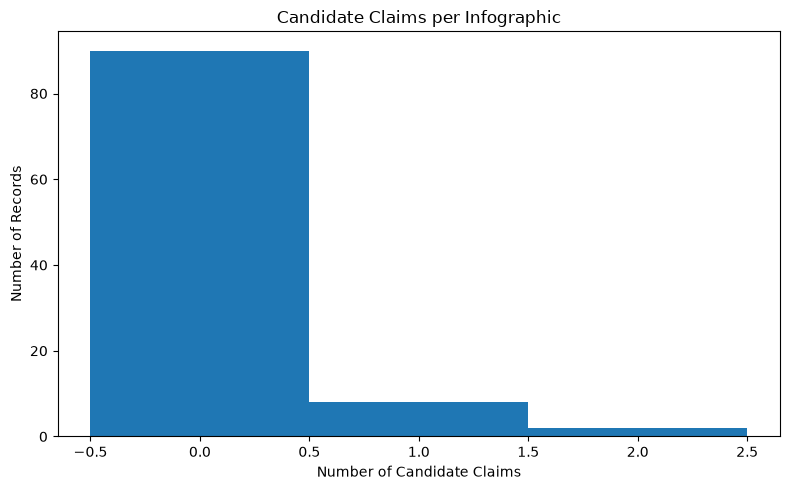

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase13\visualizations\claims_per_record.png


In [34]:
# ============================================================
# CELL 30 — Claims per record visualization
# ============================================================

claims_counts = (
    phase13_input[
        "num_candidate_claims"
    ]
)

plt.figure(
    figsize=(8, 5)
)

if claims_counts.max() > 0:

    plt.hist(
        claims_counts,
        bins=range(
            0,
            int(claims_counts.max()) + 2
        ),
        align="left"
    )

else:

    plt.hist(
        claims_counts,
        bins=1
    )

plt.xlabel(
    "Number of Candidate Claims"
)

plt.ylabel(
    "Number of Records"
)

plt.title(
    "Candidate Claims per Infographic"
)

plt.tight_layout()

CLAIMS_PLOT = (
    VIS_DIR /
    "claims_per_record.png"
)

plt.savefig(
    CLAIMS_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    CLAIMS_PLOT
)

In [35]:
# ============================================================
# CELL 31 — Records with no candidate claims
# ============================================================

no_claim_records = phase13_input[
    phase13_input[
        "num_candidate_claims"
    ] == 0
].copy()

print(
    "Records with no candidate claims:",
    len(no_claim_records)
)

display(
    no_claim_records[
        [
            "record_key",
            "source",
            "label",
            "ocr_text"
        ]
    ].head(20)
)

Records with no candidate claims: 90


,record_key,source,label,ocr_text
0,record_000000,MM-COVID19,1,WebMD
1,record_000001,MM-COVID19,1,WebMD
2,record_000002,MM-COVID19,1,WebMD
3,record_000003,MM-COVID19,1,WebMD
4,record_000004,MM-COVID19,1,WebMD
5,record_000005,MM-COVID19,1,WebMD
6,record_000006,MM-COVID19,1,WebMD
7,record_000007,MM-COVID19,1,WebMD
8,record_000008,MM-COVID19,1,WebMD
9,record_000009,MM-COVID19,1,WebMD


In [36]:
# ============================================================
# CELL 32 — Phase 13 summary
# ============================================================

phase13_summary = {

    "phase":
        "Phase 13 — Medical Claim Extraction",

    "input_records":
        int(total_records),

    "records_with_candidate_claims":
        int(records_with_claims),

    "records_without_candidate_claims":
        int(records_without_claims),

    "total_candidate_claims":
        int(total_claims),

    "average_claims_per_record":
        float(average_claims),

    "quantitative_claims":
        int(quantitative_count),

    "claim_types":
        claim_type_stats.to_dict(
            orient="records"
        ),

    "input_file":
        str(PHASE13_INPUT),

    "claim_manifest":
        str(CLAIM_MANIFEST_PATH),

    "claims_jsonl":
        str(CLAIMS_JSONL_PATH),

    "claim_json_directory":
        str(CLAIMS_DIR)
}

# Make the entire dictionary JSON safe
phase13_summary_safe = (
    make_json_serializable(
        phase13_summary
    )
)

SUMMARY_PATH = (
    METRICS_DIR /
    "claim_extraction_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        phase13_summary_safe,
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    json.dumps(
        phase13_summary_safe,
        indent=2,
        ensure_ascii=False
    )
)

{
  "phase": "Phase 13 — Medical Claim Extraction",
  "input_records": 100,
  "records_with_candidate_claims": 10,
  "records_without_candidate_claims": 90,
  "total_candidate_claims": 12,
  "average_claims_per_record": 0.12,
  "quantitative_claims": 8,
  "claim_types": [
    {
      "claim_type": "quantitative",
      "count": 8
    },
    {
      "claim_type": "unknown",
      "count": 4
    }
  ],
  "input_file": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase12\\manifests\\phase13_claim_extraction_input.csv",
  "claim_manifest": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13\\manifests\\phase13_claims_manifest.csv",
  "claims_jsonl": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13\\manifests\\phase13_claims.jsonl",
  "claim_json_directory": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase13\\claims"
}


In [37]:
# ============================================================
# CELL 33 — Phase 13 report
# ============================================================

REPORT_PATH = (
    REPORTS_DIR /
    "phase13_report.txt"
)

report_lines = [

    "PHASE 13 — MEDICAL CLAIM EXTRACTION",
    "=" * 60,
    "",

    f"Input OCR records: {total_records}",

    f"Records with candidate claims: "
    f"{records_with_claims}",

    f"Records without candidate claims: "
    f"{records_without_claims}",

    f"Total candidate claims: "
    f"{total_claims}",

    f"Average claims per record: "
    f"{average_claims:.2f}",

    f"Quantitative claims: "
    f"{quantitative_count}",

    "",

    "Claim type distribution:",
    claim_type_stats.to_string(
        index=False
    ),

    "",

    "Output files:",

    f"Claim manifest: "
    f"{CLAIM_MANIFEST_PATH}",

    f"Claims JSONL: "
    f"{CLAIMS_JSONL_PATH}",

    f"Per-record claims: "
    f"{CLAIMS_DIR}",

    "",

    "Phase 13 completed."
]

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(report_lines)
    )

print(
    "Report saved:"
)

print(
    REPORT_PATH
)

Report saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase13\reports\phase13_report.txt


In [38]:
# ============================================================
# CELL 34 — Phase 13 artifact check
# ============================================================

expected_phase13_files = [

    CLAIM_MANIFEST_PATH,

    CLAIMS_JSONL_PATH,

    SUMMARY_PATH,

    SOURCE_CLAIM_STATS,

    LABEL_CLAIM_STATS,

    CLAIMS_PLOT,

    REPORT_PATH
]

print(
    "PHASE 13 ARTIFACT CHECK"
)

print("=" * 60)

all_exist = True

for path in expected_phase13_files:

    exists = Path(path).exists()

    print(
        f"{'✓' if exists else '✗'} {path}"
    )

    if not exists:
        all_exist = False


# Check individual claim JSONs
json_count = len(
    list(
        CLAIMS_DIR.glob(
            "record_*.json"
        )
    )
)

print("=" * 60)

print(
    "Individual record JSONs:",
    json_count
)

print(
    "Expected record JSONs:",
    len(record_claim_objects)
)

if json_count != len(record_claim_objects):
    all_exist = False

print("=" * 60)

if all_exist:
    print(
        "✓ PHASE 13 ARTIFACT CHECK PASSED"
    )
else:
    print(
        "✗ SOME PHASE 13 ARTIFACTS ARE MISSING"
    )

PHASE 13 ARTIFACT CHECK
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\manifests\phase13_claims_manifest.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\manifests\phase13_claims.jsonl
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\metrics\claim_extraction_summary.json
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\metrics\source_wise_claim_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\metrics\label_wise_claim_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\visualizations\claims_per_record.png
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase13\reports\phase13_report.txt
Individual record JSONs: 10
Expected record JSONs: 10
✓ PHASE 13 ARTIFACT CHECK PASSED


In [39]:
# ============================================================
# CELL 35 — Phase 14 handoff sanity check
# ============================================================

print(
    "PHASE 14 HANDOFF"
)

print("=" * 60)

print(
    "Claim manifest:",
    CLAIM_MANIFEST_PATH
)

print(
    "Exists:",
    CLAIM_MANIFEST_PATH.exists()
)

print(
    "Total candidate claims:",
    len(candidate_claims_df)
)

print(
    "Records represented:",
    candidate_claims_df[
        "record_key"
    ].nunique()
)

print("\nClaim types:")

print(
    candidate_claims_df[
        "claim_type"
    ].value_counts()
)

print("\nSample claims:")

display(
    candidate_claims_df[
        [
            "claim_id",
            "record_key",
            "claim_text",
            "claim_type",
            "topics",
            "quantitative_values"
        ]
    ].head(10)
)

PHASE 14 HANDOFF
Claim manifest: d:\downloads\misleading-health-infographic-detection\outputs\phase13\manifests\phase13_claims_manifest.csv
Exists: True
Total candidate claims: 12
Records represented: 10

Claim types:
claim_type
quantitative    8
unknown         4
Name: count, dtype: int64

Sample claims:


,claim_id,record_key,claim_text,claim_type,topics,quantitative_values
0,claim_000000,record_000050,"The purpose of this campaign is, ""to help redu...",unknown,[other],[]
1,claim_000001,record_000062,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other],"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
2,claim_000002,record_000062,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other],"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
3,claim_000003,record_000073,-19 Vaccine COVID-19 Vaccine contains 6 doses ...,quantitative,[other],"[0.3 mL, 19, 6, 0.3]"
4,claim_000004,record_000077,Mutio 50 L01EXP ABV606 Intan (ChA) COVD 8 Inie...,quantitative,[other],"[5ml, 50, 8, 19, 07, 20, 4, 10, 8127, 2021, 9]"
5,claim_000005,record_000088,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...,unknown,[other],[]
6,claim_000006,record_000090,OFF-GRID DEVICE CAN PRODUCE WATER-ON-DEMAND WA...,unknown,[other],[]
7,claim_000007,record_000121,"The purpose of this campaign is, ""to help redu...",unknown,[other],[]
8,claim_000008,record_000136,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other],"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
9,claim_000009,record_000136,10 Multi-dose Vials No Preservative Each vial ...,quantitative,[other],"[0.5 mL, 10, 5, 0.5, 19, 2, 36, 46]"
